# Bayesian Neural Networks on SVHN
**Covers:** CNN-BNN training with MC Dropout, explicit variational Bayesian neural network training, posterior predictive uncertainty, selective prediction, and per-class uncertainty

**Instructions:** Set runtime to GPU → `Runtime > Change runtime type > GPU`


## 0. Setup & Download Data

In [1]:
!pip install scipy scikit-learn matplotlib -q

# Download SVHN .mat files directly (no upload needed)
!wget -q http://ufldl.stanford.edu/housenumbers/train_32x32.mat
!wget -q http://ufldl.stanford.edu/housenumbers/test_32x32.mat
print("Download complete!")

Download complete!


In [2]:
import time
import gc
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Load & Preprocess Data

In [3]:
train_mat = loadmat("train_32x32.mat")
test_mat  = loadmat("test_32x32.mat")

X_train_full = train_mat["X"]
y_train_full = train_mat["y"].flatten()
X_test_all   = test_mat["X"]
y_test_all   = test_mat["y"].flatten()
del train_mat, test_mat; gc.collect()

# Remap label 10 -> 0
y_train_full[y_train_full == 10] = 0
y_test_all[y_test_all == 10] = 0

# (H,W,C,N) -> (N,C,H,W), normalize to [0,1]
X_train_full = np.transpose(X_train_full, (3, 2, 0, 1)).astype(np.float32) / 255.0
X_test_all   = np.transpose(X_test_all,   (3, 2, 0, 1)).astype(np.float32) / 255.0

# Stratified train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, random_state=542, stratify=y_train_full,
)
del X_train_full, y_train_full; gc.collect()

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test_all.shape}")

Train: (58605, 3, 32, 32)  Val: (14652, 3, 32, 32)  Test: (26032, 3, 32, 32)


In [4]:
def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te, batch_size=256):
    return (
        DataLoader(TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr).long()),
                   batch_size=batch_size, shuffle=True),
        DataLoader(TensorDataset(torch.from_numpy(X_v), torch.from_numpy(y_v).long()),
                   batch_size=batch_size),
        DataLoader(TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te).long()),
                   batch_size=batch_size),
    )

train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test_all, y_test_all, batch_size=256
)

## 2. Model Definition — CNN with MC Dropout

This section defines the MC-dropout CNN using the same convolutional width pattern as the current deterministic CNN script: Conv(32), Conv(64), Conv(128), BatchNorm, MaxPool, Dense(128), and Dropout(0.3). Dropout remains active during repeated test-time forward passes for approximate Bayesian posterior prediction.


In [5]:
class BayesianCNN(nn.Module):
    """CNN with MC Dropout matched to the current deterministic CNN architecture."""

    def __init__(self, n_classes=10, dropout_p=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


## 3. Training & Evaluation Functions

In [6]:
def train_model(model, train_loader, val_loader, n_epochs=15, lr=1e-3):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    train_losses, train_accs, val_accs = [], [], []
    start = time.time()

    for epoch in range(n_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)

        train_losses.append(running_loss / total)
        train_accs.append(correct / total)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                correct += (model(xb).argmax(1) == yb).sum().item()
                total += xb.size(0)
        val_accs.append(correct / total)
        scheduler.step()

        print(f"  Epoch {epoch+1:>2}/{n_epochs}  "
              f"Loss {train_losses[-1]:.4f}  "
              f"Train {train_accs[-1]:.4f}  "
              f"Val {val_accs[-1]:.4f}")

    wall = time.time() - start
    return train_losses, train_accs, val_accs, wall


def evaluate_standard(model, loader, return_predictions=False):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb_device = xb.to(device), yb.to(device)
            preds = model(xb).argmax(1)
            correct += (preds == yb_device).sum().item()
            total += xb.size(0)
            if return_predictions:
                all_preds.append(preds.cpu().numpy())
                all_labels.append(yb.numpy())

    acc = correct / total
    if return_predictions:
        return acc, np.concatenate(all_preds), np.concatenate(all_labels)
    return acc

def mc_dropout_predict(model, loader, n_forward=30):
    """
    MC Dropout: run n_forward stochastic passes with dropout ON.
    Returns mean_probs, predictive_entropy, mutual_info, labels, accuracy.
    """
    model.train()  # keep dropout active
    all_probs = []

    for t in range(n_forward):
        batch_probs = []
        with torch.no_grad():
            for xb, _ in loader:
                logits = model(xb.to(device))
                batch_probs.append(torch.softmax(logits, 1).cpu().numpy())
        all_probs.append(np.concatenate(batch_probs, axis=0))
        if (t + 1) % 10 == 0:
            print(f"    MC pass {t+1}/{n_forward} done")

    all_probs = np.stack(all_probs, axis=0)  # (T, N, C)
    mean_probs = all_probs.mean(axis=0)       # (N, C)

    # Predictive entropy H[y | x, D]
    pred_entropy = -np.sum(mean_probs * np.log(mean_probs + 1e-10), axis=1)

    # Expected entropy E_q[H[y | x, w]]
    exp_entropy = -np.mean(
        np.sum(all_probs * np.log(all_probs + 1e-10), axis=2), axis=0
    )

    # Mutual information = epistemic uncertainty
    mutual_info = pred_entropy - exp_entropy

    labels = np.concatenate([yb.numpy() for _, yb in loader])
    mc_acc = (mean_probs.argmax(1) == labels).mean()

    return mean_probs, pred_entropy, mutual_info, labels, mc_acc

## 4. Train CNN with MC Dropout

This section trains the original CNN model using ordinary cross-entropy. The Bayesian approximation is introduced later by keeping dropout active during multiple test-time forward passes.


In [7]:
CNN_EPOCHS = 15
MC_FORWARD_PASSES = 30

model = BayesianCNN(n_classes=10, dropout_p=0.3)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}\n")

train_losses, train_accs, val_accs, train_time = train_model(
    model, train_loader, val_loader, n_epochs=CNN_EPOCHS,
)

test_acc, standard_preds, standard_true_labels = evaluate_standard(
    model, test_loader, return_predictions=True
)
standard_macro_f1 = f1_score(standard_true_labels, standard_preds, average="macro")
cnn_train_acc = train_accs[-1]
cnn_best_val_acc = max(val_accs)
standard_gap = cnn_train_acc - test_acc

print(f"\nStandard Test Accuracy: {test_acc:.4f}")
print(f"Standard Macro-F1:      {standard_macro_f1:.4f}")
print(f"Standard Gap:           {standard_gap:.4f}")
print(f"Training Time:          {train_time:.1f}s")

Parameters: 357,258

  Epoch  1/15  Loss 1.4686  Train 0.4871  Val 0.8183
  Epoch  2/15  Loss 0.7598  Train 0.7521  Val 0.8582
  Epoch  3/15  Loss 0.6405  Train 0.7945  Val 0.8827
  Epoch  4/15  Loss 0.5570  Train 0.8217  Val 0.8777
  Epoch  5/15  Loss 0.5025  Train 0.8398  Val 0.8856
  Epoch  6/15  Loss 0.4713  Train 0.8485  Val 0.8878
  Epoch  7/15  Loss 0.4420  Train 0.8580  Val 0.9023
  Epoch  8/15  Loss 0.4145  Train 0.8641  Val 0.8999
  Epoch  9/15  Loss 0.3754  Train 0.8754  Val 0.9108
  Epoch 10/15  Loss 0.3520  Train 0.8849  Val 0.9158
  Epoch 11/15  Loss 0.3303  Train 0.8913  Val 0.9114
  Epoch 12/15  Loss 0.3193  Train 0.8956  Val 0.9100
  Epoch 13/15  Loss 0.3006  Train 0.9012  Val 0.9152
  Epoch 14/15  Loss 0.2938  Train 0.9023  Val 0.9148
  Epoch 15/15  Loss 0.2819  Train 0.9054  Val 0.9157

Standard Test Accuracy: 0.9150
Standard Macro-F1:      0.9076
Standard Gap:           -0.0096
Training Time:          54.9s


## 5. MC Dropout Posterior Predictive Inference

This section performs repeated stochastic forward passes with dropout turned on. The mean predicted probability gives the prediction, while predictive entropy and mutual information summarize uncertainty.


In [8]:
print(f"Running MC Dropout ({MC_FORWARD_PASSES} forward passes)...")
mc_start = time.time()
mean_probs, pred_entropy, mutual_info, true_labels, mc_acc = mc_dropout_predict(
    model, test_loader, n_forward=MC_FORWARD_PASSES,
)
mc_time = time.time() - mc_start

mc_preds = mean_probs.argmax(axis=1)
correct_mask = mc_preds == true_labels
mc_macro_f1 = f1_score(true_labels, mc_preds, average="macro")
mc_gap = cnn_train_acc - mc_acc

print(f"MC Dropout Test Accuracy: {mc_acc:.4f}")
print(f"MC Dropout Macro-F1:      {mc_macro_f1:.4f}")
print(f"MC Dropout Gap:           {mc_gap:.4f}")
print(f"MC Inference Time:        {mc_time:.1f}s")

Running MC Dropout (30 forward passes)...
    MC pass 10/30 done
    MC pass 20/30 done
    MC pass 30/30 done
MC Dropout Test Accuracy: 0.9169
MC Dropout Macro-F1:      0.9097
MC Dropout Gap:           -0.0116
MC Inference Time:        26.4s


## 6. Explicit Variational Bayesian Neural Network

The MC Dropout CNN above is an approximate Bayesian method, but the network weights themselves are still point estimates. This section adds a more explicit Bayesian neural network using Bayes-by-Backprop. Each BayesianLinear layer learns a Gaussian variational posterior over its weights and biases. Training minimizes an ELBO-style objective: classification negative log-likelihood plus a KL divergence penalty to a standard normal prior.


In [9]:
class BayesianLinear(nn.Module):
    """Linear layer with a diagonal Gaussian variational posterior over weights and biases."""

    def __init__(self, in_features, out_features, prior_sigma=1.0):
        super().__init__()
        self.prior_sigma = prior_sigma

        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features).normal_(0.0, 0.05))
        self.weight_rho = nn.Parameter(torch.empty(out_features, in_features).normal_(-5.0, 0.1))
        self.bias_mu = nn.Parameter(torch.zeros(out_features))
        self.bias_rho = nn.Parameter(torch.empty(out_features).normal_(-5.0, 0.1))

        self.log_prior = torch.tensor(0.0)
        self.log_variational_posterior = torch.tensor(0.0)

    @staticmethod
    def _log_normal(x, mu, sigma):
        return (
            -0.5 * math.log(2 * math.pi)
            - torch.log(sigma)
            - (x - mu).pow(2) / (2 * sigma.pow(2))
        ).sum()

    def forward(self, x, sample=True):
        weight_sigma = F.softplus(self.weight_rho)
        bias_sigma = F.softplus(self.bias_rho)

        if self.training or sample:
            weight = self.weight_mu + weight_sigma * torch.randn_like(weight_sigma)
            bias = self.bias_mu + bias_sigma * torch.randn_like(bias_sigma)
        else:
            weight = self.weight_mu
            bias = self.bias_mu

        prior_sigma = torch.tensor(self.prior_sigma, device=x.device)
        self.log_prior = self._log_normal(weight, torch.zeros_like(weight), prior_sigma)
        self.log_prior += self._log_normal(bias, torch.zeros_like(bias), prior_sigma)

        self.log_variational_posterior = self._log_normal(weight, self.weight_mu, weight_sigma)
        self.log_variational_posterior += self._log_normal(bias, self.bias_mu, bias_sigma)

        return F.linear(x, weight, bias)



class VariationalBNN(nn.Module):
    """Bayes-by-Backprop BNN matched to the current FCN hidden widths."""

    def __init__(self, input_dim=32 * 32 * 3, hidden_dims=(512, 256, 128), n_classes=10):
        super().__init__()
        dims = [input_dim, *hidden_dims, n_classes]
        self.layers = nn.ModuleList(
            [BayesianLinear(dims[j], dims[j + 1]) for j in range(len(dims) - 1)]
        )

    def forward(self, x, sample=True):
        x = x.view(x.size(0), -1)
        x = (x - 0.5) / 0.5
        for layer in self.layers[:-1]:
            x = F.relu(layer(x, sample=sample))
        return self.layers[-1](x, sample=sample)

    def kl_divergence(self):
        log_prior = sum(layer.log_prior for layer in self.layers)
        log_var_post = sum(layer.log_variational_posterior for layer in self.layers)
        return log_var_post - log_prior


In [10]:
def evaluate_variational_bnn(model, loader, n_forward=30):
    """Posterior predictive evaluation by sampling Bayesian weights."""
    model.eval()
    all_probs = []

    with torch.no_grad():
        for _ in range(n_forward):
            batch_probs = []
            for xb, _ in loader:
                xb = xb.to(device)
                logits = model(xb, sample=True)
                batch_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
            all_probs.append(np.concatenate(batch_probs, axis=0))

    all_probs = np.stack(all_probs, axis=0)
    mean_probs = all_probs.mean(axis=0)
    pred_entropy = -np.sum(mean_probs * np.log(mean_probs + 1e-10), axis=1)
    exp_entropy = -np.mean(
        np.sum(all_probs * np.log(all_probs + 1e-10), axis=2),
        axis=0,
    )
    mutual_info = pred_entropy - exp_entropy

    labels = np.concatenate([yb.numpy() for _, yb in loader])
    acc = (mean_probs.argmax(axis=1) == labels).mean()
    return mean_probs, pred_entropy, mutual_info, labels, acc


def train_variational_bnn(model, train_loader, val_loader, n_epochs=15, lr=1e-3, kl_weight=1.0):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    n_train = len(train_loader.dataset)

    history = {"loss": [], "nll": [], "kl": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    best_state = None
    start = time.time()

    for epoch in range(1, n_epochs + 1):
        model.train()
        total_loss, total_nll, total_kl = 0.0, 0.0, 0.0
        correct, total = 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()

            logits = model(xb, sample=True)
            nll = F.cross_entropy(logits, yb)
            kl = model.kl_divergence() / n_train
            loss = nll + kl_weight * kl

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_nll += nll.item() * xb.size(0)
            total_kl += kl.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += xb.size(0)

        train_acc = correct / total
        val_acc = evaluate_variational_bnn(model, val_loader, n_forward=5)[4]

        history["loss"].append(total_loss / total)
        history["nll"].append(total_nll / total)
        history["kl"].append(total_kl / total)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"  Epoch {epoch:>2}/{n_epochs}  "
            f"Loss {history['loss'][-1]:.4f}  "
            f"NLL {history['nll'][-1]:.4f}  "
            f"KL {history['kl'][-1]:.4f}  "
            f"Train {train_acc:.4f}  "
            f"Val {val_acc:.4f}"
        )

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    wall = time.time() - start
    return history, wall, best_val_acc


## 7. Train and Evaluate Variational BNN

This section trains the explicit Bayesian neural network and evaluates its posterior predictive distribution using multiple sampled weight configurations. The architecture is intentionally smaller than the CNN so it can run reasonably in Colab while still demonstrating direct Bayesian weight uncertainty.


In [11]:
VI_BNN_EPOCHS = 15
VI_BNN_FORWARD_PASSES = 30

vi_bnn = VariationalBNN(input_dim=32 * 32 * 3, hidden_dims=(512, 256, 128), n_classes=10)
vi_bnn_params = sum(p.numel() for p in vi_bnn.parameters())
print(f"Variational BNN parameters: {vi_bnn_params:,}")

vi_history, vi_train_time, vi_best_val_acc = train_variational_bnn(
    vi_bnn,
    train_loader,
    val_loader,
    n_epochs=VI_BNN_EPOCHS,
    lr=1e-3,
    kl_weight=1.0,
)

print(f"\nRunning variational BNN posterior prediction ({VI_BNN_FORWARD_PASSES} forward passes)...")
vi_start = time.time()
vi_mean_probs, vi_pred_entropy, vi_mutual_info, vi_true_labels, vi_test_acc = evaluate_variational_bnn(
    vi_bnn,
    test_loader,
    n_forward=VI_BNN_FORWARD_PASSES,
)
vi_predict_time = time.time() - vi_start
vi_preds = vi_mean_probs.argmax(axis=1)
vi_macro_f1 = f1_score(vi_true_labels, vi_preds, average="macro")
vi_train_acc = vi_history["train_acc"][-1]
vi_gap = vi_train_acc - vi_test_acc

print("\nVariational BNN Results")
print("=" * 40)
print(f"Best validation accuracy:      {vi_best_val_acc:.4f}")
print(f"Test accuracy:                 {vi_test_acc:.4f}")
print(f"Macro-F1:                      {vi_macro_f1:.4f}")
print(f"Gap:                           {vi_gap:.4f}")
print(f"Training time:                 {vi_train_time:.1f}s")
print(f"Posterior predictive time:     {vi_predict_time:.1f}s")
print(f"Mean predictive entropy:       {vi_pred_entropy.mean():.4f}")
print(f"Mean mutual information:       {vi_mutual_info.mean():.4f}")


Variational BNN parameters: 3,477,780
  Epoch  1/15  Loss 131.7115  NLL 1.3398  KL 130.3717  Train 0.5567  Val 0.6865
  Epoch  2/15  Loss 124.7033  NLL 0.8582  KL 123.8450  Train 0.7344  Val 0.7522
  Epoch  3/15  Loss 118.1262  NLL 0.7323  KL 117.3940  Train 0.7757  Val 0.7711
  Epoch  4/15  Loss 111.6676  NLL 0.6529  KL 111.0147  Train 0.8005  Val 0.7898
  Epoch  5/15  Loss 105.3380  NLL 0.6048  KL 104.7332  Train 0.8137  Val 0.7968
  Epoch  6/15  Loss 99.1364  NLL 0.5640  KL 98.5724  Train 0.8257  Val 0.8038
  Epoch  7/15  Loss 93.1066  NLL 0.5449  KL 92.5617  Train 0.8302  Val 0.8040
  Epoch  8/15  Loss 87.2774  NLL 0.5280  KL 86.7494  Train 0.8351  Val 0.8133
  Epoch  9/15  Loss 81.7011  NLL 0.5256  KL 81.1755  Train 0.8347  Val 0.8137
  Epoch 10/15  Loss 76.4051  NLL 0.5245  KL 75.8806  Train 0.8343  Val 0.8114
  Epoch 11/15  Loss 71.4013  NLL 0.5086  KL 70.8927  Train 0.8396  Val 0.8142
  Epoch 12/15  Loss 66.7635  NLL 0.5260  KL 66.2375  Train 0.8317  Val 0.7979
  Epoch 13/15  L

## 8. Plots

This section keeps the original visualizations for the MC Dropout CNN training curve and uncertainty analysis.


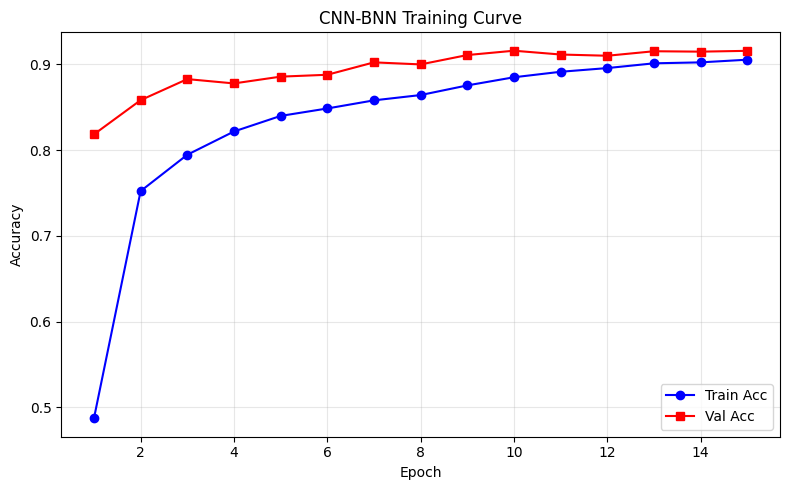

In [12]:
# Training curve
fig, ax = plt.subplots(figsize=(8, 5))
ep = range(1, CNN_EPOCHS + 1)
ax.plot(ep, train_accs, "b-o", label="Train Acc")
ax.plot(ep, val_accs, "r-s", label="Val Acc")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_title("CNN-BNN Training Curve")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

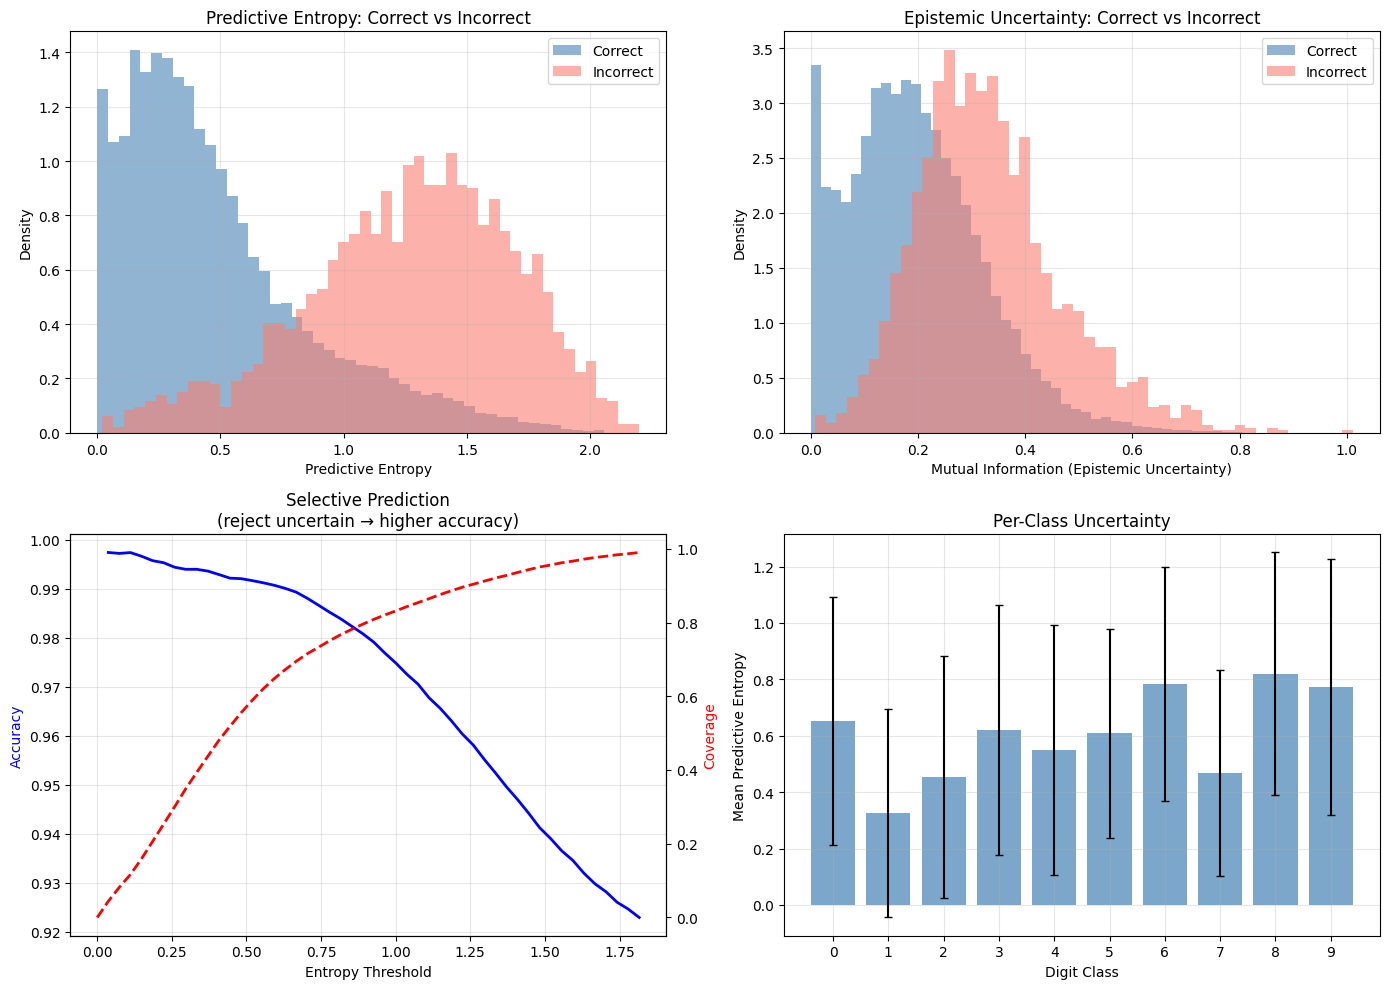

In [13]:
# Uncertainty analysis (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Predictive entropy
axes[0, 0].hist(pred_entropy[correct_mask], bins=50, alpha=0.6,
                density=True, color="steelblue", label="Correct")
axes[0, 0].hist(pred_entropy[~correct_mask], bins=50, alpha=0.6,
                density=True, color="salmon", label="Incorrect")
axes[0, 0].set_xlabel("Predictive Entropy")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_title("Predictive Entropy: Correct vs Incorrect")
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# (b) Epistemic uncertainty
axes[0, 1].hist(mutual_info[correct_mask], bins=50, alpha=0.6,
                density=True, color="steelblue", label="Correct")
axes[0, 1].hist(mutual_info[~correct_mask], bins=50, alpha=0.6,
                density=True, color="salmon", label="Incorrect")
axes[0, 1].set_xlabel("Mutual Information (Epistemic Uncertainty)")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Epistemic Uncertainty: Correct vs Incorrect")
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# (c) Selective prediction
thresholds = np.linspace(0, np.percentile(pred_entropy, 99), 50)
sel_accs, sel_cov = [], []
for t in thresholds:
    m = pred_entropy <= t
    if m.sum() > 0:
        sel_accs.append((mc_preds[m] == true_labels[m]).mean())
        sel_cov.append(m.mean())
    else:
        sel_accs.append(np.nan); sel_cov.append(0)

ax_l = axes[1, 0]; ax_r = ax_l.twinx()
ax_l.plot(thresholds, sel_accs, "b-", lw=2)
ax_r.plot(thresholds, sel_cov, "r--", lw=2)
ax_l.set_xlabel("Entropy Threshold")
ax_l.set_ylabel("Accuracy", color="b")
ax_r.set_ylabel("Coverage", color="r")
ax_l.set_title("Selective Prediction\n(reject uncertain → higher accuracy)")
ax_l.grid(True, alpha=0.3)

# (d) Per-class uncertainty
cls_ent = [pred_entropy[true_labels == c].mean() for c in range(10)]
cls_std = [pred_entropy[true_labels == c].std() for c in range(10)]
axes[1, 1].bar(range(10), cls_ent, yerr=cls_std, capsize=3,
               color="steelblue", alpha=0.7)
axes[1, 1].set_xlabel("Digit Class")
axes[1, 1].set_ylabel("Mean Predictive Entropy")
axes[1, 1].set_title("Per-Class Uncertainty")
axes[1, 1].set_xticks(range(10))
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

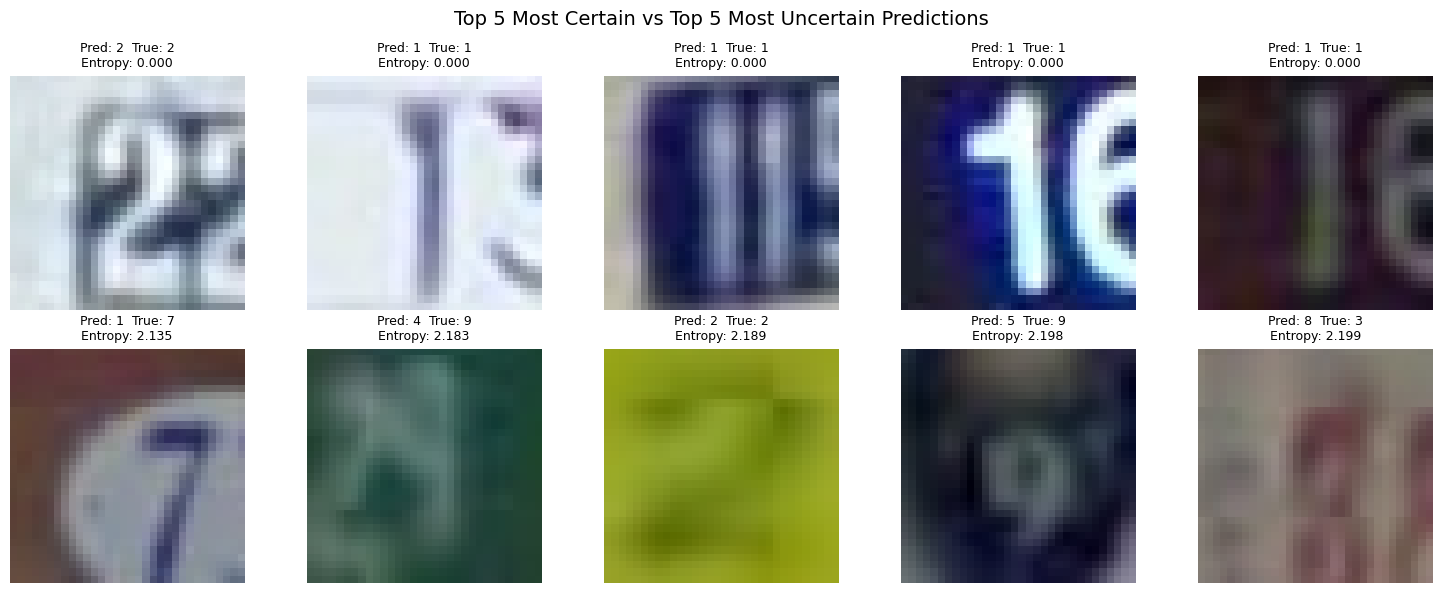

In [14]:
# Most certain vs most uncertain example images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Top 5 Most Certain vs Top 5 Most Uncertain Predictions", fontsize=14)

most_certain = np.argsort(pred_entropy)[:5]
most_uncertain = np.argsort(pred_entropy)[-5:]

for i, idx in enumerate(most_certain):
    img = X_test_all[idx].transpose(1, 2, 0)  # (C,H,W) -> (H,W,C)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Pred: {mc_preds[idx]}  True: {true_labels[idx]}\n"
                         f"Entropy: {pred_entropy[idx]:.3f}", fontsize=9)
    axes[0, i].axis("off")
axes[0, 0].set_ylabel("Most Certain", fontsize=11)

for i, idx in enumerate(most_uncertain):
    img = X_test_all[idx].transpose(1, 2, 0)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Pred: {mc_preds[idx]}  True: {true_labels[idx]}\n"
                         f"Entropy: {pred_entropy[idx]:.3f}", fontsize=9)
    axes[1, i].axis("off")
axes[1, 0].set_ylabel("Most Uncertain", fontsize=11)

plt.tight_layout()
plt.show()

## 9. Variational BNN Plots

This section visualizes the explicit Bayesian neural network results: training behavior, posterior predictive uncertainty, selective prediction, and examples with the lowest and highest predictive entropy.


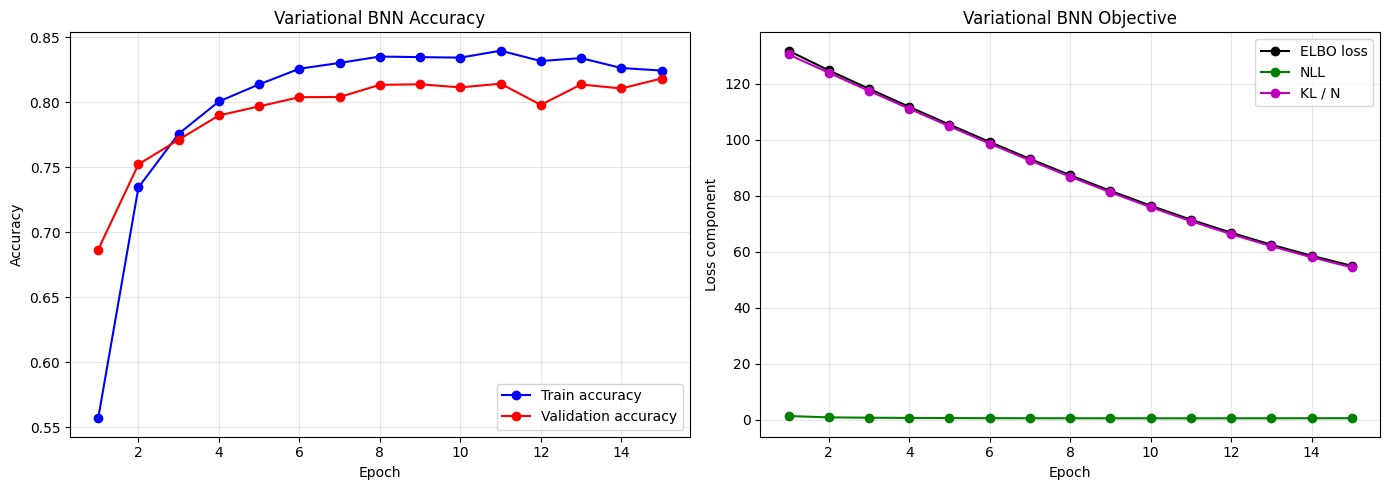

In [15]:
# Variational BNN training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, VI_BNN_EPOCHS + 1)

axes[0].plot(ep, vi_history["train_acc"], "b-o", label="Train accuracy")
axes[0].plot(ep, vi_history["val_acc"], "r-o", label="Validation accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Variational BNN Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, vi_history["loss"], "k-o", label="ELBO loss")
axes[1].plot(ep, vi_history["nll"], "g-o", label="NLL")
axes[1].plot(ep, vi_history["kl"], "m-o", label="KL / N")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss component")
axes[1].set_title("Variational BNN Objective")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


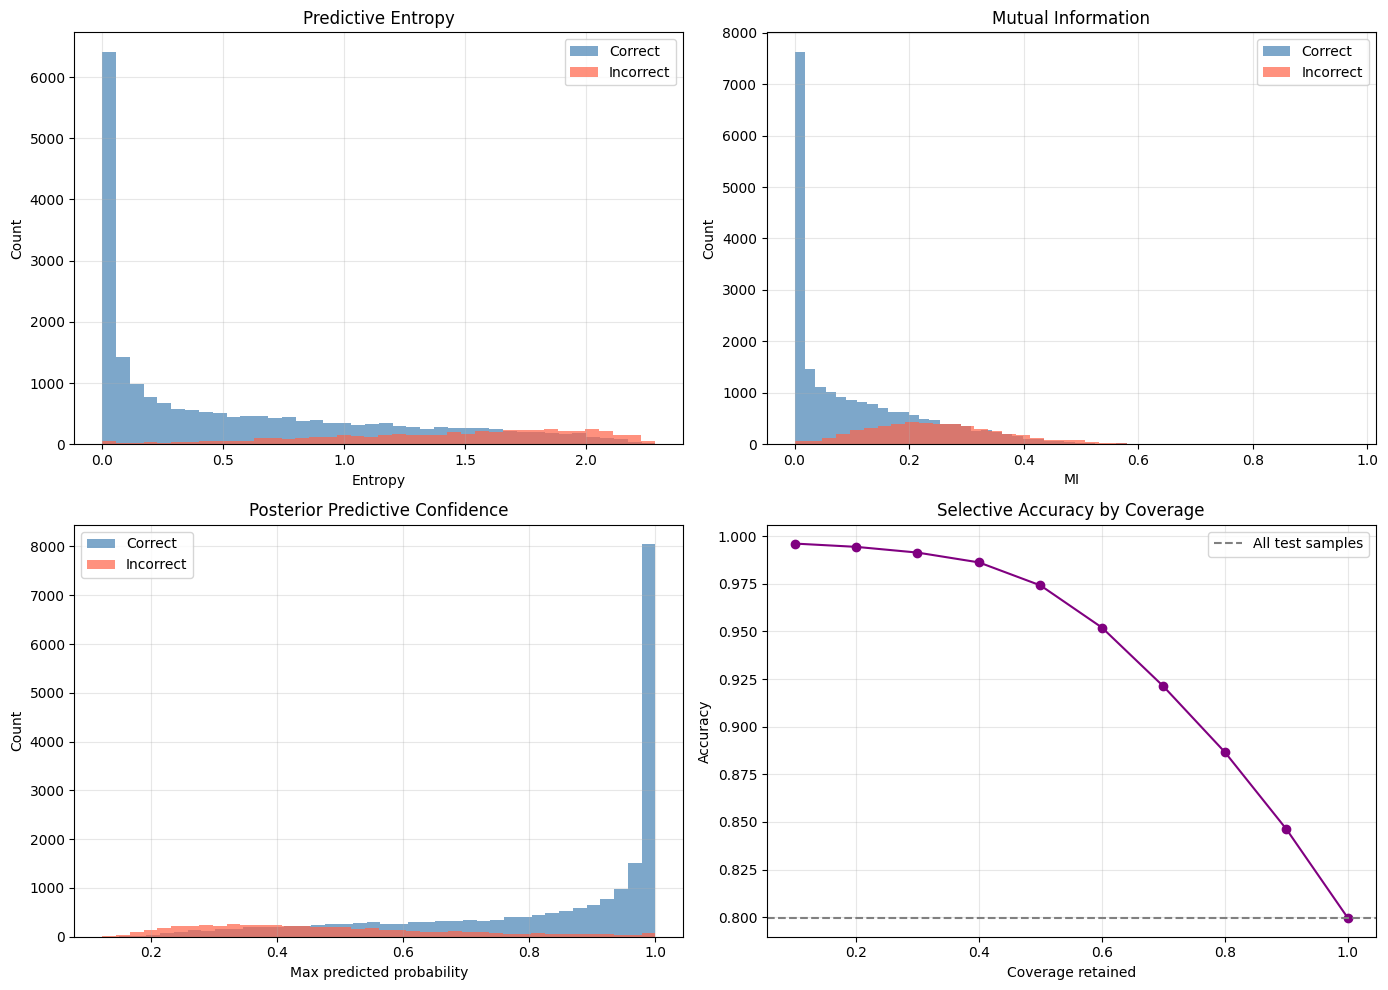

In [16]:
# Variational BNN uncertainty analysis
vi_preds = vi_mean_probs.argmax(axis=1)
vi_correct = vi_preds == vi_true_labels
vi_confidence = vi_mean_probs.max(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Predictive entropy
axes[0, 0].hist(vi_pred_entropy[vi_correct], bins=40, alpha=0.7, label="Correct", color="steelblue")
axes[0, 0].hist(vi_pred_entropy[~vi_correct], bins=40, alpha=0.7, label="Incorrect", color="tomato")
axes[0, 0].set_title("Predictive Entropy")
axes[0, 0].set_xlabel("Entropy")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# (b) Mutual information
axes[0, 1].hist(vi_mutual_info[vi_correct], bins=40, alpha=0.7, label="Correct", color="steelblue")
axes[0, 1].hist(vi_mutual_info[~vi_correct], bins=40, alpha=0.7, label="Incorrect", color="tomato")
axes[0, 1].set_title("Mutual Information")
axes[0, 1].set_xlabel("MI")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# (c) Confidence histogram
axes[1, 0].hist(vi_confidence[vi_correct], bins=40, alpha=0.7, label="Correct", color="steelblue")
axes[1, 0].hist(vi_confidence[~vi_correct], bins=40, alpha=0.7, label="Incorrect", color="tomato")
axes[1, 0].set_title("Posterior Predictive Confidence")
axes[1, 0].set_xlabel("Max predicted probability")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# (d) Selective prediction: keep lowest-entropy examples
coverages = np.linspace(0.1, 1.0, 10)
selective_acc = []
order = np.argsort(vi_pred_entropy)
for coverage in coverages:
    n_keep = int(len(order) * coverage)
    keep = order[:n_keep]
    selective_acc.append(vi_correct[keep].mean())

axes[1, 1].plot(coverages, selective_acc, "o-", color="purple")
axes[1, 1].axhline(vi_test_acc, color="gray", linestyle="--", label="All test samples")
axes[1, 1].set_title("Selective Accuracy by Coverage")
axes[1, 1].set_xlabel("Coverage retained")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


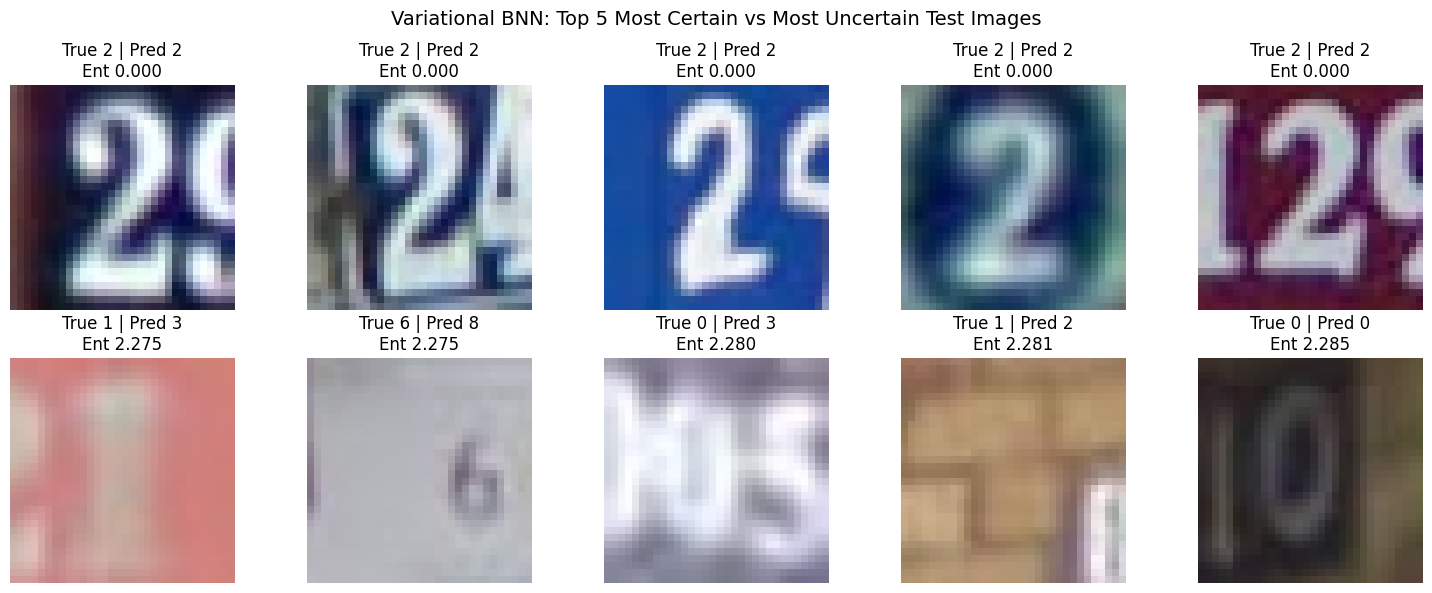

In [17]:
# Variational BNN most certain vs most uncertain example images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Variational BNN: Top 5 Most Certain vs Most Uncertain Test Images", fontsize=14)

certain_idx = np.argsort(vi_pred_entropy)[:5]
uncertain_idx = np.argsort(vi_pred_entropy)[-5:]

for j, idx in enumerate(certain_idx):
    img = X_test_all[idx].transpose(1, 2, 0)
    axes[0, j].imshow(img)
    axes[0, j].set_title(
        f"True {vi_true_labels[idx]} | Pred {vi_preds[idx]}\n"
        f"Ent {vi_pred_entropy[idx]:.3f}"
    )
    axes[0, j].axis("off")

for j, idx in enumerate(uncertain_idx):
    img = X_test_all[idx].transpose(1, 2, 0)
    axes[1, j].imshow(img)
    axes[1, j].set_title(
        f"True {vi_true_labels[idx]} | Pred {vi_preds[idx]}\n"
        f"Ent {vi_pred_entropy[idx]:.3f}"
    )
    axes[1, j].axis("off")

axes[0, 0].set_ylabel("Most certain", fontsize=12)
axes[1, 0].set_ylabel("Most uncertain", fontsize=12)
plt.tight_layout()
plt.show()


## 10. Results Summary

This section prints a compact summary for both Bayesian approaches: the original MC Dropout CNN and the explicit variational BNN.


In [18]:
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)

print(f"\nModel: CNN-BNN (MC Dropout, p=0.3)")
print(f"Parameters:             {n_params:,}")
print(f"Training Epochs:        {CNN_EPOCHS}")
print(f"Final Train Accuracy:   {cnn_train_acc:.4f}")
print(f"Best Val Accuracy:      {cnn_best_val_acc:.4f}")
print(f"Standard Test Accuracy: {test_acc:.4f}")
print(f"Standard Macro-F1:      {standard_macro_f1:.4f}")
print(f"Standard Gap:           {standard_gap:.4f}")
print(f"MC Dropout Test Acc:    {mc_acc:.4f}")
print(f"MC Dropout Macro-F1:    {mc_macro_f1:.4f}")
print(f"MC Dropout Gap:         {mc_gap:.4f}")

print(f"\nUncertainty Statistics:")
print(f"  Mean entropy (correct):    {pred_entropy[correct_mask].mean():.4f}")
print(f"  Mean entropy (incorrect):  {pred_entropy[~correct_mask].mean():.4f}")
print(f"  Mean MI (correct):         {mutual_info[correct_mask].mean():.4f}")
print(f"  Mean MI (incorrect):       {mutual_info[~correct_mask].mean():.4f}")

print(f"\nSelective Prediction:")
for pct in [90, 80, 70, 50]:
    thresh = np.percentile(pred_entropy, pct)
    m = pred_entropy <= thresh
    acc = (mc_preds[m] == true_labels[m]).mean()
    print(f"  Keep top {pct:>2}% confident -> Acc = {acc:.4f}  (coverage = {m.mean():.2%})")

if 'vi_test_acc' in globals():
    print(f"\nModel: Variational BNN (Bayes-by-Backprop)")
    print(f"Parameters:             {vi_bnn_params:,}")
    print(f"Training Epochs:        {VI_BNN_EPOCHS}")
    print(f"Final Train Accuracy:   {vi_train_acc:.4f}")
    print(f"Best Val Accuracy:      {vi_best_val_acc:.4f}")
    print(f"Posterior Test Acc:     {vi_test_acc:.4f}")
    print(f"Posterior Macro-F1:     {vi_macro_f1:.4f}")
    print(f"Posterior Gap:          {vi_gap:.4f}")
    print(f"Mean Pred Entropy:      {vi_pred_entropy.mean():.4f}")
    print(f"Mean Mutual Info:       {vi_mutual_info.mean():.4f}")


RESULTS SUMMARY

Model: CNN-BNN (MC Dropout, p=0.3)
Parameters:             357,258
Training Epochs:        15
Final Train Accuracy:   0.9054
Best Val Accuracy:      0.9158
Standard Test Accuracy: 0.9150
Standard Macro-F1:      0.9076
Standard Gap:           -0.0096
MC Dropout Test Acc:    0.9169
MC Dropout Macro-F1:    0.9097
MC Dropout Gap:         -0.0116

Uncertainty Statistics:
  Mean entropy (correct):    0.4880
  Mean entropy (incorrect):  1.2648
  Mean MI (correct):         0.1944
  Mean MI (incorrect):       0.3314

Selective Prediction:
  Keep top 90% confident -> Acc = 0.9594  (coverage = 90.00%)
  Keep top 80% confident -> Acc = 0.9804  (coverage = 80.00%)
  Keep top 70% confident -> Acc = 0.9890  (coverage = 70.00%)
  Keep top 50% confident -> Acc = 0.9924  (coverage = 50.00%)

Model: Variational BNN (Bayes-by-Backprop)
Parameters:             3,477,780
Training Epochs:        15
Final Train Accuracy:   0.8243
Best Val Accuracy:      0.8182
Posterior Test Acc:     0.7996
P